In [1]:
!pip install -q langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.2 MB/s eta 0:00:00


In [2]:
!pip install -q langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 13.8 MB/s eta 0:00:00


In [3]:
from google.colab import userdata
import os
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")

## Graph

In [5]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_state: str

In [24]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

In [25]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:

    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state']

    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"

    # 50% of the time, we return Node 3
    return "node_3"

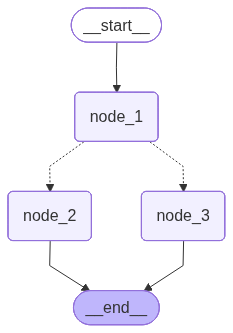

In [26]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:

graph.invoke({"graph_state" : "Hi, this is Tanishq."})

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Tanishq. I am happy!'}

## Messages

In [8]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [ ]:
result = llm.invoke(messages)

In [ ]:
result.pretty_print()

================================== Ai Message ==================================

<think>
Okay, the user wants to know the best places in the US to see orcas. Let me start by recalling my knowledge on this. The most famous spot is definitely the Pacific Northwest, especially around Washington State and British Columbia. The Salish Sea, which includes areas like the San Juan Islands and Puget Sound, is a hotspot for orca sightings. There are different populations there, like the Southern Resident Killer Whales, which are the ones that are often targeted for viewing.

I should mention specific locations within Washington. The San Juan Islands are a top recommendation because they have a good number of tours, and the orcas are a regular sight there. Also, the inland passage near Victoria, BC, is close enough to consider. Maybe mention that the best time is spring to fall when the orcas are in the area. 

Another place is Alaska. Southeast Alaska, near Juneau, is another good spot. However

In [14]:
def calculate(a: int, b: int, c: str) -> int:
    """Calculate operations on operands a and b.

    Args:
        a: first int
        b: second int
        c: operation to perform, one of ["*", "/", "+", "-"]

    Returns:
        int: result of operation
    """
    if c == "*":
        return a*b
    elif c == "/":
        return a/b
    elif c == "+":
        return a+b
    elif c == "-":
        return a-b
    else:
        raise ValueError(f"Invalid operation {c}")

llm_with_tools = llm.bind_tools([calculate])

In [15]:
result = llm_with_tools.invoke([HumanMessage(content=f"What is 562 multiplied by 467 and the result added to 1556?", name="Lance")])

In [17]:
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s tackle the user\'s question: "What is 562 multiplied by 467 and the result added to 1556?" Alright, first, I need to break down the problem into steps. The user wants to multiply 562 by 467 and then add 1556 to the result. \n\nHmm, I should check if I can use the provided calculate function for each step. The function takes two integers and an operation. So first, I need to calculate 562 * 467. Let me do that first multiplication. But wait, maybe I should verify if the function can handle multiplication. The operation parameter allows one of the four operations: multiply, divide, add, subtract. So yes, multiplication is allowed.\n\nSo, the first step is to call the calculate function with a=562, b=467, c="*". That should give the product. Then, once I have that result, I need to add 1556 to it. For the second step, I\'ll use the same calculate function again, taking the result from the first step as \'a\' and 1

In [20]:
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages

In [ ]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='0682dd39-3877-4a0e-90b7-8cd9d3dd96bb'),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='76a072db-d372-4475-9fa7-d9627d173f8b'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='9b86a946-3526-4f94-b8df-58b29851ec5e')]

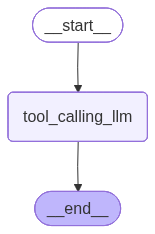

In [ ]:
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [ ]:
messages["messages"] = add_messages(messages["messages"], HumanMessage(content="I'm looking for information on marine biology. what is the class of fish?"))
messages = graph.invoke(messages)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?
================================ Human Message =================================

I'm looking for information on marine biology. what is the class of fish?
================================== Ai Message ==================================

Fish are classified into several classes under the phylum **Chordata**, including:
1. **Actinopterygii** (ray-finned fish): E.g., salmon, tuna, and most bony fish.
2. **Sarcopterygii** (lobe-finned fish): Includes coelacanths and lungfish (though lungfish are freshwater).
3. **Chondrichthyes** (cartilaginous fish): E.g., sharks, rays, and chimaeras.
4. **Agnatha** (jawless fish): E.g., hagfish and lampreys.

In marine biology, most studied fish belong to **Actinopterygii** and **Chondrichthyes**. Let me know if you'd like deeper details! 😊


In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

## agent

In [18]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [21]:
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

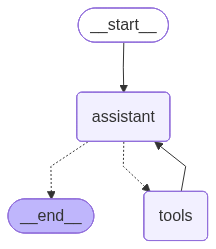

In [27]:
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

react_graph = builder.compile()
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [28]:
messages = []
messages = add_messages(messages, HumanMessage(content="562 is multiplied by 467 and the product is added to 1556. the final sum is divided by 5. what is the answer?"))
result = react_graph.invoke({"messages": messages})
messages = result["messages"]
for m in messages:
    m.pretty_print()

================================ Human Message =================================

562 is multiplied by 467 and the product is added to 1556. the final sum is divided by 5. what is the answer?
================================== Ai Message ==================================
Tool Calls:
  multiply (1knhw7t94)
 Call ID: 1knhw7t94
  Args:
    a: 562
    b: 467
================================= Tool Message =================================
Name: multiply

262454
================================== Ai Message ==================================
Tool Calls:
  add (rjdrggmeg)
 Call ID: rjdrggmeg
  Args:
    a: 262454
    b: 1556
================================= Tool Message =================================
Name: add

264010
================================== Ai Message ==================================
Tool Calls:
  divide (gdy78qkb9)
 Call ID: gdy78qkb9
  Args:
    a: 264010
    b: 5
================================= Tool Message =================================
Name: divide

52802.0
======

In [32]:
result["messages"]

[HumanMessage(content='562 is multiplied by 467 and the product is added to 1556. the final sum is divided by 5. what is the answer?', additional_kwargs={}, response_metadata={}, id='a1f399b5-544f-463f-9067-936c502d2681'),
 AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants me to calculate 562 multiplied by 467, then add 1556 to that product, and finally divide the sum by 5. Hmm, I need to break this down step by step.\n\nFirst, the multiplication part: 562 times 467. I remember that multiplying large numbers can be done by breaking them into smaller parts. Let me think, 562 * 467. Maybe I can use the standard multiplication method. But since I'm supposed to use the provided functions, I should call the multiply function here. So, the first step is to multiply 562 and 467 using the multiply tool.\n\nOnce I get the product, the next step is to add 1556 to it. So, I'll take the result from the first step and use the add function with 1556. Then

In [ ]:
messages = add_messages(messages, HumanMessage(content="please divide that by 2"))
result = react_graph.invoke({"messages": messages})
messages = result["messages"]
for m in messages:
    m.pretty_print()

================================ Human Message =================================

562 is multiplied by 467 and the product is added to 1556. the final sum is divided by 5. what is the answer?
================================== Ai Message ==================================
Tool Calls:
  multiply (hxys09yn6)
 Call ID: hxys09yn6
  Args:
    a: 562
    b: 467
================================= Tool Message =================================
Name: multiply

262454
================================== Ai Message ==================================
Tool Calls:
  add (n74y6x331)
 Call ID: n74y6x331
  Args:
    a: 262454
    b: 1556
================================= Tool Message =================================
Name: add

264010
================================== Ai Message ==================================
Tool Calls:
  divide (tq3gjp40t)
 Call ID: tq3gjp40t
  Args:
    a: 264010
    b: 5
================================= Tool Message =================================
Name: divide

52802.0
======

## memory
- one way to introduce memory is as above. send all previous messages in subsequent calls.
- another way is to use persistence

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

In [ ]:
# now use a thread id to refer to earlier conversations
config = {"configurable": {"thread_id": "1"}}

messages = [HumanMessage(content="what is 22 times 4")]
result = react_graph_memory.invoke({"messages": messages}, config)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 22 times 4
================================== Ai Message ==================================
Tool Calls:
  multiply (n2sgggq83)
 Call ID: n2sgggq83
  Args:
    a: 22
    b: 4
================================= Tool Message =================================
Name: multiply

88
================================== Ai Message ==================================

The result of 22 multiplied by 4 is 88.


In [ ]:
messages = [HumanMessage(content="can you divide that be 11?")]
result = react_graph_memory.invoke({"messages": messages}, config)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 22 times 4
================================== Ai Message ==================================
Tool Calls:
  multiply (n2sgggq83)
 Call ID: n2sgggq83
  Args:
    a: 22
    b: 4
================================= Tool Message =================================
Name: multiply

88
================================== Ai Message ==================================

The result of 22 multiplied by 4 is 88.
================================ Human Message =================================

can you divide that be 11?
================================== Ai Message ==================================
Tool Calls:
  divide (4jhapsegx)
 Call ID: 4jhapsegx
  Args:
    a: 88
    b: 11
================================= Tool Message =================================
Name: divide

8.0
================================== Ai Message ==================================

The result of dividing 88 by 11 is **8.0**.
